In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline

# Class 9: Business Cycle Data

## Import data

In [2]:
# Read rbc_data.csv into a Pandas DataFrame with the first column set as the index and parse_dates=True
df = pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/computational-macroeconomics/master/Data/Csv/rbc_data_actual_trend_cycle.csv',index_col=0,parse_dates=True)

## Aggregate RBC data

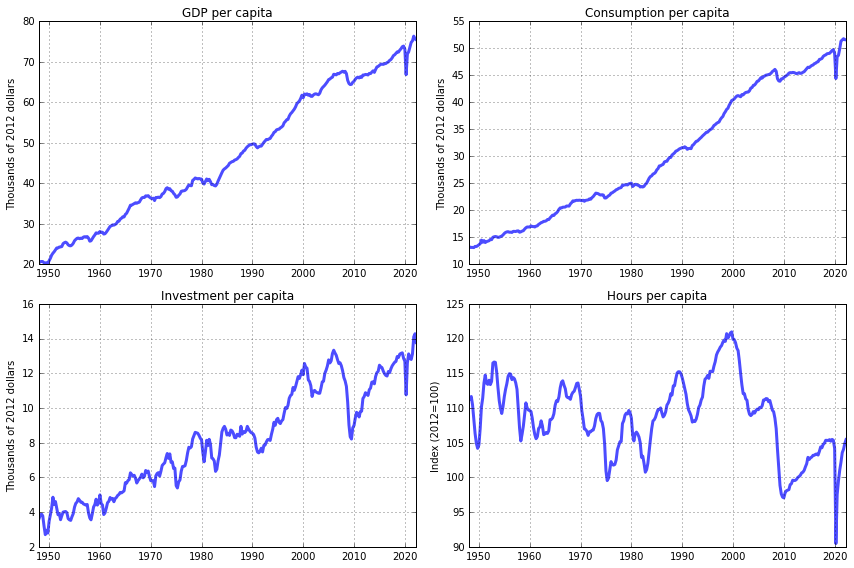

In [3]:
# Construct a 2x2 grid of plots of GDP, consumption, investment, and hours.
base_year = '2012'
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(2,2,1)
ax1.plot(df.gdp,'-',lw=3,alpha = 0.7)
ax1.grid()
ax1.set_title('GDP per capita')
ax1.set_ylabel('Thousands of '+base_year+' dollars')

ax2 = fig.add_subplot(2,2,2)
ax2.plot(df.consumption,'-',lw=3,alpha = 0.7)
ax2.grid()
ax2.set_title('Consumption per capita')
ax2.set_ylabel('Thousands of '+base_year+' dollars')

ax3 = fig.add_subplot(2,2,3)
ax3.plot(df.investment,'-',lw=3,alpha = 0.7)
ax3.grid()
ax3.set_title('Investment per capita')
ax3.set_ylabel('Thousands of '+base_year+' dollars')

ax4 = fig.add_subplot(2,2,4)
ax4.plot(df.hours,'-',lw=3,alpha = 0.7)
ax4.grid()
ax4.set_title('Hours per capita')
ax4.set_ylabel('Index ('+base_year+'=100)')

fig.tight_layout()

# Save image and make LaTex figure
figName = '009_rbc_aggregate_data'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{GDP, consumption, investment, and hours} for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 7.cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

## GDP: Actual and Trend

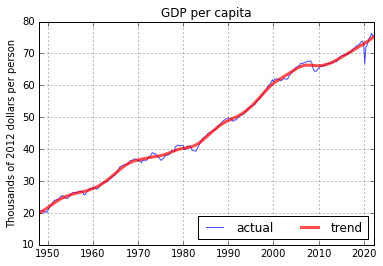

In [4]:
# Construct a plot of real GDP with its trend with:
plt.plot(df.gdp,'-',lw=1,alpha = 0.7,label='actual')
plt.plot(df.gdp_trend,'r-',lw=3,alpha = 0.7,label='trend')
plt.grid()
plt.ylabel('Thousands of '+base_year+' dollars per person')
plt.title('GDP per capita')
plt.legend(loc='lower right',ncol=2)


# Save image and make LaTex figure
figName = '009_rbc_gdp_actual_trend'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{GDP, consumption, investment, and hours} per capita for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 7.cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

## GDP: Actual, Trend, and Cycle

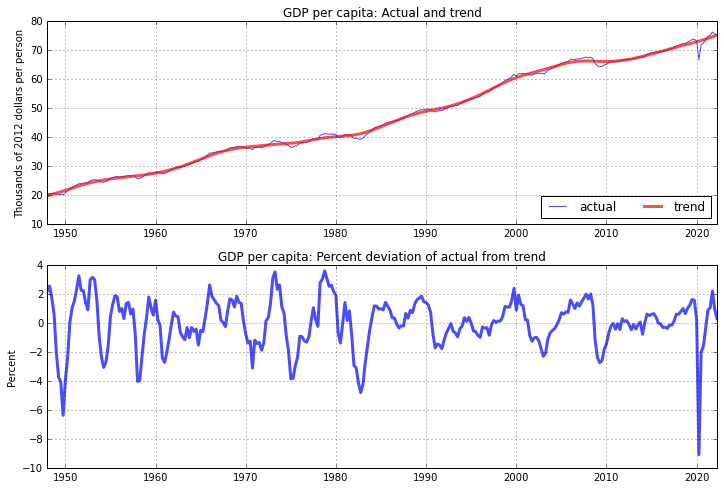

In [5]:
fig = plt.figure(figsize=(12,8))

# Construct a plot of real GDP with its trend with:
ax1 = fig.add_subplot(2,1,1)
ax1.plot(df.gdp,'-',lw=1,alpha = 0.7,label='actual')
ax1.plot(df.gdp_trend,'r-',lw=3,alpha = 0.7,label='trend')
ax1.grid()
ax1.set_ylabel('Thousands of '+base_year+' dollars per person')
ax1.set_title('GDP per capita: Actual and trend')
ax1.legend(loc='lower right',ncol=2)

ax2 = fig.add_subplot(2,1,2)
ax2.plot(df.gdp_cycle*100,'b-',lw=3,alpha = 0.7)
ax2.set_ylabel('Percent')
# ax2.set_ylim([-2,2])
ax2.set_title('GDP per capita: Percent deviation of actual from trend')
ax2.grid()


# Save image and make LaTex figure
figName = '009_rbc_gdp_aggregate_and_cyclical_data'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{US GDP per capita:} actual, trend, and cycle from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 7.cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

## Standard Deviation and Correlation Tables

In [6]:
# Make smaller DataFrame with appropriate column names for table
df_cycle = df.copy()[['gdp_cycle','consumption_cycle','investment_cycle','hours_cycle']]*100
df_cycle.columns = ['GDP','Consumption','Investment','Hours']

In [7]:
# Standard deviations
std_devs = df_cycle.std().round(3)
print(std_devs)
std_devs = std_devs.to_latex(header=False)

# Construct LaTeX table
tabName = '009_rbc_data_std_devs'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Standard deviations of real business cycle data} from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. Units are percent deviations from trend. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+std_devs+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

GDP            1.688
Consumption    1.337
Investment     7.400
Hours          2.063
dtype: float64


/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6626/2690267308.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  std_devs = std_devs.to_latex(header=False)


In [8]:
# Correlations
correlations = df_cycle.corr().round(3)
print(correlations)
correlations = correlations.to_latex()

# Construct LaTeX table
tabName = '009_rbc_data_correlations'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Correlations of real business cycle data} from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. Units are percent deviations from trend. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+correlations+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

               GDP  Consumption  Investment  Hours
GDP          1.000        0.814       0.836  0.884
Consumption  0.814        1.000       0.645  0.757
Investment   0.836        0.645       1.000  0.764
Hours        0.884        0.757       0.764  1.000


/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6626/2053210488.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  correlations = correlations.to_latex()


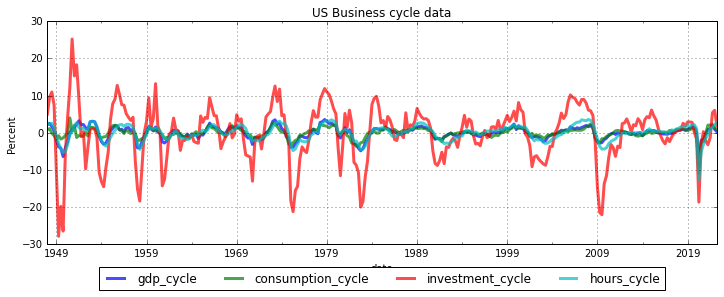

In [9]:
# Plot the cyclical components of GDP, consumption, investment, and hours (all times 100) on the same set of axes
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,1,1)
(df[['gdp_cycle','consumption_cycle','investment_cycle','hours_cycle']]*100).plot(ax = ax,legend=False,lw=3,alpha=0.7)
ax.legend(['GDP','Consumption','Investment','Hours'],loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=4)
ax.set_ylabel('Percent')
ax.set_title('US Business cycle data')
ax.grid()


# Save image and make LaTex figure
figName = '009_rbc_all_cyclical_data'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Business cycle components of GDP, consumption, investment, and hours} for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()